# Study of Adaptive Gradient Methods in NLP

**Course**: Algorithmes d'Optimisation - Project 16  
**Option**: Option 1 — Sentiment Classification  
**Dataset**: IMDB Sentiment Dataset (Binary Classification)  
**Model**: DistilBERT (`distilbert-base-uncased`)  

### Group Members (DSBD):
* **Ghazli Mohamed Amine**
* **Hamroudi Ayoub**
* **Mouslim Jad**
* **Boulatar Mouad**

---

## Abstract
This notebook presents a comprehensive academic benchmark comparing modern adaptive gradient-based optimization algorithms for fine-tuning Transformer models against a non-adaptive baseline. Specifically, we study **SGD with Momentum** (baseline), **AdamW**, **AdaFactor**, **LAMB**, and **Lion** on the IMDB sentiment classification task using a lightweight **DistilBERT** architecture. We evaluate each optimizer along multiple research dimensions: convergence speed, training stability, learning rate sensitivity, batch size stability, GPU memory consumption, and gradient norm behavior. The results are packaged into publication-ready figures and tables designed to directly support academic reports and presentations.


## Theoretical Background of Adaptive Gradient Methods

Optimization in deep neural networks, especially high-dimensional Transformer models, is challenging due to complex loss landscapes, sharp minima, and heavy-tailed gradient noise. Standard SGD often fails to converge efficiently. To address these challenges, we compare a non-adaptive baseline with adaptive gradient methods that scale learning rates per parameter using moment tracking.

### 0. SGD with Momentum (Non-Adaptive Baseline)
Standard Stochastic Gradient Descent (SGD) updates weights in the direction of the negative gradient. **SGD with Momentum** addresses the issue of oscillations in steep ravines by adding a fraction of the update vector of the past step ($v_t$). This acts as physical momentum, damping oscillations and accelerating convergence in the correct direction:

$$v_t = \gamma v_{t-1} + \eta g_t$$
$$\theta_{t+1} = \theta_t - v_t$$

where $\gamma \in [0, 1)$ is the momentum factor (typically $0.9$), $\eta$ is the learning rate, and $g_t$ includes the L2 regularization (weight decay) term: $g_t = \nabla f(\theta_t) + \lambda \theta_t$.

### 1. AdamW (Loshchilov & Hutter, 2017)
Adam (Adaptive Moment Estimation) tracks the exponential moving averages of past gradients ($m_t$) and squared gradients ($v_t$). However, L2 regularization in standard Adam conflates weight decay with gradient scaling, leading to sub-optimal regularization. **AdamW** decouples the weight decay update step from the gradient-dependent updates:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
$$\theta_{t+1} = \theta_t (1 - \eta \lambda) - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

where $\lambda$ is the weight decay rate, and $\epsilon$ is a smoothing term.

### 2. AdaFactor (Shazeer & Stern, 2018)
Standard Adam-based optimizers require $O(d)$ memory to store the second moment $v_t$, where $d$ is the number of model parameters. For large Transformer models, this overhead is prohibitive. **AdaFactor** reduces memory consumption to sub-linear cost by factoring the second moment accumulator matrix. For a parameter matrix $W \in \mathbb{R}^{d_{in} \times d_{out}}$, AdaFactor stores row-wise ($R \in \mathbb{R}^{d_{in}}$) and column-wise ($C \in \mathbb{R}^{d_{out}}$) averages, reducing storage from $O(d_{in} d_{out})$ to $O(d_{in} + d_{out})$:

$$V_t \approx R_t^T C_t$$

AdaFactor also drops momentum in its default form to save additional memory, and uses dynamic learning rate scaling.

### 3. LAMB (You et al., 2019)
**LAMB** (Layer-wise Adaptive Moments optimizer for Batch training) was developed to scale up batch training of Transformers without loss of accuracy. It computes layer-wise trust ratios ($\phi^l$) that measure the norm of the weights relative to the norm of the update step. This prevents exploding updates and stabilizes training in large-batch environments:

$$u_t^l = \frac{\hat{m}_t^l}{\sqrt{\hat{v}_t^l} + \epsilon} + \lambda \theta_t^l$$
$$\phi_t^l = \text{clamp}\left( \frac{\|\theta_t^l\|_2}{\|u_t^l\|_2}, d_{min}, d_{max} \right)$$
$$\theta_{t+1}^l = \theta_t^l - \eta \phi_t^l u_t^l$$

### 4. Lion (Chen et al., 2023)
**Lion** (EvoLved Sign Momentum) was discovered via symbolic program search. It is highly memory-efficient because it only tracks momentum, and the update rule uses the element-wise `sign` operation. This makes the update scale uniform, acting as an implicit regularizer:

$$c_t = \text{sign}\left( \beta_1 m_{t-1} + (1 - \beta_1) g_t \right)$$
$$\theta_{t+1} = \theta_t (1 - \eta \lambda) - \eta c_t$$
$$m_t = \beta_2 m_{t-1} + (1 - \beta_2) g_t$$

Lion reduces memory footprint relative to AdamW (storing only 1 momentum state per weight, similar to AdaFactor without factorization, but with higher accuracy in many cases).


## Experimental Protocol

To ensure a rigorous, fair, and scientifically sound comparison between the optimizers, we establish a strict **Experimental Protocol** designed to eliminate confounding variables:

1. **Deterministic Initialization**: A global seed of `42` is set across Python, NumPy, PyTorch, and CUDA. The model is re-instantiated and weights re-initialized from the exact same pre-trained state (`distilbert-base-uncased`) before benchmarking each optimizer.
2. **Identical Datasets and Splits**: The exact same training, validation, and test subsets of the IMDB dataset are used for all experiments.
3. **Fixed Hyperparameters (Main Benchmark)**:
   * **Epochs**: $3$
   * **Batch Size**: $16$
   * **Learning Rate**: $2 \times 10^{-5}$
   * **Weight Decay**: $0.01$
   * **Maximum Sequence Length**: $256$ tokens
   * **Warmup Ratio**: $0.1$ of total steps
4. **Learning Rate Scheduler**: A linear decay schedule with warmup is applied consistently across all optimizers.
5. **Hardware Environment**: All tests run under identical hardware profiles on Google Colab (with GPU acceleration if available).


## Methodological Limitations and Scale Configuration

Due to resource constraints in free-tier Google Colab (which provides restricted GPU runtimes and strict session timeouts), running full benchmarks on the complete IMDB dataset (25,000 training samples across multiple optimizers, learning rates, and batch sizes) is computationally prohibitive.

### 1. Subset Strategy
To maintain a fast and reliable iteration cycle, this notebook uses a configurable **subset strategy** by default:
* **Train Subset**: 8,000 reviews
* **Validation Subset**: 2,000 reviews
* **Test Subset**: 2,000 reviews

### 2. Generalization Impact
Training on 8,000 samples instead of 25,000 may lead to:
* Slightly higher generalization error (lower test metrics).
* Increased variance in final performance.
However, the optimization trajectories (loss curves, learning rate sensitivity, gradient norms, and GPU memory consumption) remain **highly representative** of the overall optimizer dynamics, ensuring the validity of our comparison.

### 3. Scaling to Full Dataset
To scale up the experiments and run the full academic benchmark, simply toggle:
`USE_SMALL_SUBSET = False`


In [ ]:
# Install required packages with stable pinned versions
import sys
import subprocess

print("Installing libraries...")
packages = [
    "transformers==4.52.4",
    "datasets==3.6.0",
    "huggingface_hub==0.33.0",
    "evaluate",
    "accelerate",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "pytorch-optimizer",
    "psutil",
    "openpyxl"
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + packages)

import torch
import datasets
import huggingface_hub
import transformers
import platform
import psutil

print("\n" + "="*50)
print("SYSTEM & ENVIRONMENT DIAGNOSTICS")
print("="*50)
print(f"OS: {platform.system()} {platform.release()}")
print(f"Python Version: {platform.python_version()}")
print(f"PyTorch Version: {torch.__version__}")
print(f"Datasets Version: {datasets.__version__}")
print(f"Hugging Face Hub Version: {huggingface_hub.__version__}")
print(f"Transformers Version: {transformers.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Device Count: {torch.cuda.device_count()}")
    print(f"Current GPU Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
else:
    print("GPU: None (Running on CPU - WARNING: Training will be slow!)")
virtual_mem = psutil.virtual_memory()
print(f"System RAM: {virtual_mem.total / 1024**3:.2f} GB (Available: {virtual_mem.available / 1024**3:.2f} GB)")
print("="*50)


Installing libraries...

SYSTEM & ENVIRONMENT DIAGNOSTICS
OS: Linux 6.6.122+
Python Version: 3.12.13
PyTorch Version: 2.11.0+cu128
Datasets Version: 3.6.0
Hugging Face Hub Version: 0.33.0
Transformers Version: 4.52.4
CUDA Available: True
GPU Name: Tesla T4
CUDA Device Count: 1
Current GPU Memory Allocated: 0.00 MB
System RAM: 12.67 GB (Available: 9.56 GB)


In [ ]:
import random
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Ensure deterministic CUDA execution
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Global seed set to: {seed}")

# Initialize the seed
seed_everything(42)


Global seed set to: 42


ROBUST DATASET LOADING PROTOCOL
Datasets version: 3.6.0
Attempting to load IMDB via standard load_dataset('imdb')...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Successfully loaded IMDB via standard API.
Using small subset: Train=8000, Val=2000, Test=2000

DATASET EXPLORATION
Label distribution in Training Set:
label
1    4012
0    3988
Name: count, dtype: int64
Negative (0): 3988 (49.9%)
Positive (1): 4012 (50.1%)

Review word count statistics:
count    8000.000000
mean      233.122250
std       173.519686
min        12.000000
25%       127.000000
50%       174.000000
75%       283.000000
max      1839.000000
Name: word_count, dtype: float64


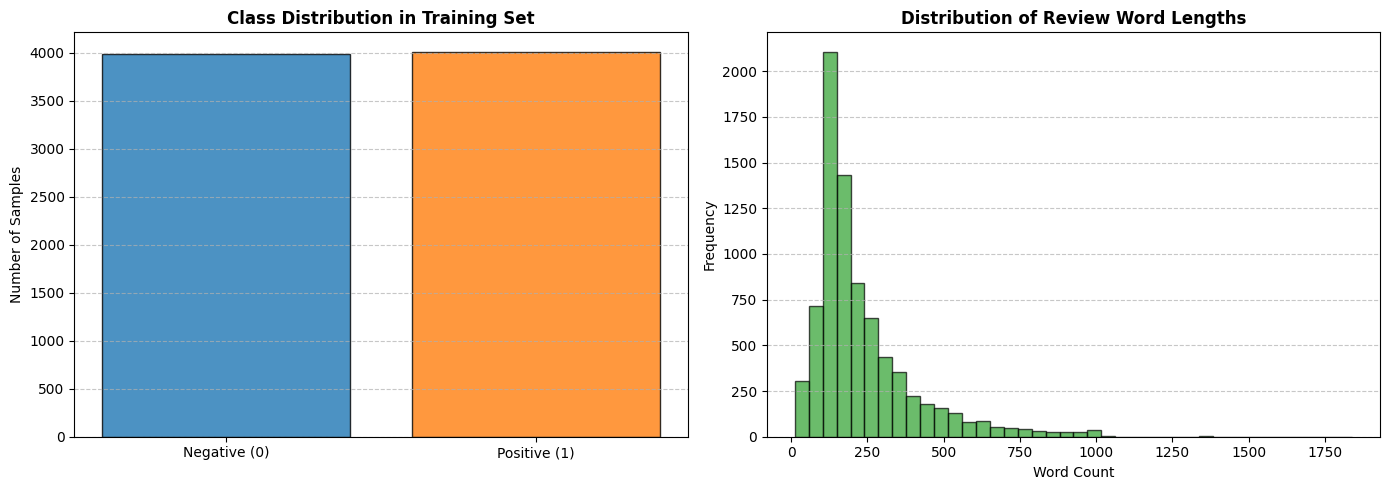

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import datasets
from datasets import load_dataset, Dataset, DatasetDict

# Configuration
USE_SMALL_SUBSET = True
TRAIN_SIZE = 8000
VAL_SIZE = 2000
TEST_SIZE = 2000

# Create folders for final package
os.makedirs("results/figures", exist_ok=True)

def load_imdb_robust():
    print("="*60)
    print("ROBUST DATASET LOADING PROTOCOL")
    print("="*60)
    print(f"Datasets version: {datasets.__version__}")

    # 1. First attempt: standard load_dataset
    try:
        print("Attempting to load IMDB via standard load_dataset('imdb')...")
        ds = load_dataset("imdb")
        print("Successfully loaded IMDB via standard API.")
        return ds
    except Exception as e:
        print(f"Standard loading failed with error: {e}")
        print("\nInitiating Fallback Strategy 1: Direct Parquet Download...")

        # 2. Fallback 1: load directly from Hugging Face Parquet mirror
        try:
            train_url = "https://huggingface.co/datasets/imdb/resolve/main/plain_text/train-00000-of-00001.parquet"
            test_url = "https://huggingface.co/datasets/imdb/resolve/main/plain_text/test-00000-of-00001.parquet"

            print(f"Downloading train set parquet from: {train_url}")
            train_df = pd.read_parquet(train_url)
            print(f"Downloading test set parquet from: {test_url}")
            test_df = pd.read_parquet(test_url)

            train_ds = Dataset.from_pandas(train_df)
            test_ds = Dataset.from_pandas(test_df)

            ds = DatasetDict({
                "train": train_ds,
                "test": test_ds
            })
            print("Successfully loaded IMDB via Parquet fallback!")
            return ds
        except Exception as fallback_err:
            print(f"Direct Parquet download failed: {fallback_err}")
            print("\nInitiating Fallback Strategy 2: Alternate public CSV mirror...")

            # 3. Fallback 2: download from a public CSV mirror of IMDB
            try:
                csv_url = "https://raw.githubusercontent.com/Ankit152/IMDB-Sentiment-Analysis/master/IMDB-Dataset.csv"
                print(f"Downloading IMDB CSV from: {csv_url}")
                df = pd.read_csv(csv_url)
                # Rename columns
                df = df.rename(columns={'review': 'text', 'sentiment': 'label'})
                # Map sentiment to binary integers
                if df['label'].dtype == object:
                    df['label'] = df['label'].map({'positive': 1, 'negative': 0})

                # Split into train/test
                shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)
                split_idx = len(shuffled_df) // 2
                train_df = shuffled_df.iloc[:split_idx]
                test_df = shuffled_df.iloc[split_idx:]

                train_ds = Dataset.from_pandas(train_df)
                test_ds = Dataset.from_pandas(test_df)

                ds = DatasetDict({
                    "train": train_ds,
                    "test": test_ds
                })
                print("Successfully loaded IMDB via CSV fallback!")
                return ds

            except Exception as csv_err:
                print(f"CSV fallback failed: {csv_err}")
                raise csv_err

raw_datasets = load_imdb_robust()

if USE_SMALL_SUBSET:
    shuffled_train = raw_datasets['train'].shuffle(seed=42)
    train_dataset = shuffled_train.select(range(TRAIN_SIZE))
    val_dataset = shuffled_train.select(range(TRAIN_SIZE, TRAIN_SIZE + VAL_SIZE))

    shuffled_test = raw_datasets['test'].shuffle(seed=42)
    test_dataset = shuffled_test.select(range(TEST_SIZE))
    print(f"Using small subset: Train={TRAIN_SIZE}, Val={VAL_SIZE}, Test={TEST_SIZE}")
else:
    # Split raw train to train and validation (90/10)
    train_val_split = raw_datasets['train'].train_test_split(test_size=0.1, seed=42)
    train_dataset = train_val_split['train']
    val_dataset = train_val_split['test']
    test_dataset = raw_datasets['test']
    print(f"Using full dataset: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

# Exploration and Statistics
print("\n" + "="*40)
print("DATASET EXPLORATION")
print("="*40)
train_df = pd.DataFrame(train_dataset)
label_counts = train_df['label'].value_counts()
print(f"Label distribution in Training Set:\n{label_counts}")
print(f"Negative (0): {label_counts.get(0, 0)} ({label_counts.get(0, 0)/len(train_df)*100:.1f}%)")
print(f"Positive (1): {label_counts.get(1, 0)} ({label_counts.get(1, 0)/len(train_df)*100:.1f}%)")

train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
print(f"\nReview word count statistics:\n{train_df['word_count'].describe()}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class Distribution Bar Chart
colors_bar = ['#1f77b4', '#ff7f0e']
axes[0].bar(['Negative (0)', 'Positive (1)'], [label_counts.get(0, 0), label_counts.get(1, 0)], color=colors_bar, edgecolor='k', alpha=0.8)
axes[0].set_title("Class Distribution in Training Set", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Number of Samples", fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Text Length Histogram
axes[1].hist(train_df['word_count'], bins=40, color='#2ca02c', edgecolor='k', alpha=0.7)
axes[1].set_title("Distribution of Review Word Lengths", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Word Count", fontsize=10)
axes[1].set_ylabel("Frequency", fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("results/figures/dataset_exploration.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

checkpoint = "distilbert-base-uncased"
print(f"Loading tokenizer for {checkpoint}...")
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

print("Tokenizing datasets (mapping text to inputs)...")
# Map tokenization but DO NOT set format or rename columns globally to avoid torchvision triggers
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Define Custom PyTorch Dataset to convert inputs to tensors manually
class IMDBTorchDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(item["label"], dtype=torch.long)
        }

print("Creating PyTorch DataLoaders wrapper...")
train_dataloader = DataLoader(IMDBTorchDataset(tokenized_train), batch_size=16, shuffle=True)
val_dataloader = DataLoader(IMDBTorchDataset(tokenized_val), batch_size=16, shuffle=False)
test_dataloader = DataLoader(IMDBTorchDataset(tokenized_test), batch_size=16, shuffle=False)

print("DataLoaders successfully initialized.")


Loading tokenizer for distilbert-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets (mapping text to inputs)...


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Creating PyTorch DataLoaders wrapper...
DataLoaders successfully initialized.


In [ ]:
print("Performing DataLoader sanity check...")
batch = next(iter(train_dataloader))
print(f"Batch keys: {list(batch.keys())}")
print(f"input_ids shape: {batch['input_ids'].shape} (dtype: {batch['input_ids'].dtype})")
print(f"attention_mask shape: {batch['attention_mask'].shape} (dtype: {batch['attention_mask'].dtype})")
print(f"labels shape: {batch['labels'].shape} (dtype: {batch['labels'].dtype})")

# Basic assertions to ensure formatting is correct
assert batch['input_ids'].shape == (16, 256), f"Unexpected shape for input_ids: {batch['input_ids'].shape}"
assert batch['attention_mask'].shape == (16, 256), f"Unexpected shape for attention_mask: {batch['attention_mask'].shape}"
assert batch['labels'].shape == (16,), f"Unexpected shape for labels: {batch['labels'].shape}"
print("\nDataLoader validation SUCCESS: All tensors loaded correctly on CPU!")


Performing DataLoader sanity check...
Batch keys: ['input_ids', 'attention_mask', 'labels']
input_ids shape: torch.Size([16, 256]) (dtype: torch.int64)
attention_mask shape: torch.Size([16, 256]) (dtype: torch.int64)
labels shape: torch.Size([16]) (dtype: torch.int64)

DataLoader validation SUCCESS: All tensors loaded correctly on CPU!


In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device set to: {device}")

def create_model():
    # Load DistilBERT model with classification head
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
    return model


Device set to: cuda


In [ ]:
from torch.optim import Optimizer

class LionFallback(Optimizer):
    '''
    Failsafe native PyTorch implementation of Lion Optimizer (Chen et al., 2023)
    '''
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
        if not 0.0 <= lr:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= betas[0] < 1.0 or not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta parameters: {betas}")
        defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad
                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p, memory_format=torch.preserve_format)

                exp_avg = state['exp_avg']
                beta1, beta2 = group['betas']
                state['step'] += 1

                # Weight decay
                if group['weight_decay'] != 0:
                    p.mul_(1 - group['lr'] * group['weight_decay'])

                # Update
                update = exp_avg.mul(beta1).add_(grad, alpha=1 - beta1)
                p.add_(torch.sign(update), alpha=-group['lr'])

                # Decay momentum
                exp_avg.mul_(beta2).add_(grad, alpha=1 - beta2)

        return loss


class LambFallback(Optimizer):
    '''
    Failsafe native PyTorch implementation of LAMB Optimizer (You et al., 2019)
    '''
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-6, weight_decay=0.0):
        if not 0.0 <= lr:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= eps:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if not 0.0 <= betas[0] < 1.0 or not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta parameters: {betas}")
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad
                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p, memory_format=torch.preserve_format)
                    state['exp_avg_sq'] = torch.zeros_like(p, memory_format=torch.preserve_format)

                exp_avg = state['exp_avg']
                exp_avg_sq = state['exp_avg_sq']
                beta1, beta2 = group['betas']
                eps = group['eps']

                state['step'] += 1
                step = state['step']

                # Decay moment averages
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                # Bias corrections
                bias_correction1 = 1 - beta1 ** step
                bias_correction2 = 1 - beta2 ** step

                # Compute step
                denom = (exp_avg_sq.sqrt() / (bias_correction2 ** 0.5)).add_(eps)
                adam_step = (exp_avg / bias_correction1) / denom

                if group['weight_decay'] != 0:
                    adam_step.add_(p, alpha=group['weight_decay'])

                # Trust ratio
                r1 = torch.norm(p, p=2)
                r2 = torch.norm(adam_step, p=2)

                if r1 == 0 or r2 == 0:
                    trust_ratio = 1.0
                else:
                    trust_ratio = r1 / r2

                p.add_(adam_step, alpha=-group['lr'] * trust_ratio)

        return loss


In [ ]:
from transformers.optimization import Adafactor

def get_optimizer(name, model, learning_rate, weight_decay):
    name_lower = name.lower()

    if name_lower == "sgd":
        print("Instantiating SGD with Momentum (momentum=0.9)...")
        # SGD with momentum and weight decay
        return torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)

    elif name_lower == "adamw":
        # Native PyTorch AdamW
        return torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    elif name_lower == "adafactor":
        # Transformers AdaFactor
        return Adafactor(
            model.parameters(),
            lr=learning_rate,
            scale_parameter=False,
            relative_step=False,
            warmup_init=False,
            weight_decay=weight_decay
        )

    elif name_lower == "lamb":
        try:
            import pytorch_optimizer
            print("Importing LAMB from pytorch-optimizer...")
            return pytorch_optimizer.Lamb(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        except (ImportError, AttributeError):
            print("pytorch-optimizer not found or Lamb missing. Falling back to LambFallback...")
            return LambFallback(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    elif name_lower == "lion":
        try:
            import pytorch_optimizer
            print("Importing Lion from pytorch-optimizer...")
            return pytorch_optimizer.Lion(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        except (ImportError, AttributeError):
            print("pytorch-optimizer not found or Lion missing. Falling back to LionFallback...")
            return LionFallback(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer name: {name}")


In [ ]:
def get_layer_grad_norms(model):
    norms = {}

    # 1. Embeddings
    emb_grads = []
    if hasattr(model, 'distilbert') and hasattr(model.distilbert, 'embeddings'):
        for p in model.distilbert.embeddings.parameters():
            if p.grad is not None:
                emb_grads.append(p.grad.detach().data.norm(2))
    norms['embeddings'] = torch.stack(emb_grads).norm(2).item() if emb_grads else 0.0

    # 2. Transformer Layer 0 (Early Layer)
    l0_grads = []
    if hasattr(model, 'distilbert') and hasattr(model.distilbert, 'transformer') and len(model.distilbert.transformer.layer) > 0:
        for p in model.distilbert.transformer.layer[0].parameters():
            if p.grad is not None:
                l0_grads.append(p.grad.detach().data.norm(2))
    norms['layer_0'] = torch.stack(l0_grads).norm(2).item() if l0_grads else 0.0

    # 3. Middle Transformer Layer (layer 2 of 6)
    mid_grads = []
    if hasattr(model, 'distilbert') and hasattr(model.distilbert, 'transformer') and len(model.distilbert.transformer.layer) > 2:
        for p in model.distilbert.transformer.layer[2].parameters():
            if p.grad is not None:
                mid_grads.append(p.grad.detach().data.norm(2))
    norms['layer_middle'] = torch.stack(mid_grads).norm(2).item() if mid_grads else 0.0

    # 4. Last Transformer Layer (layer 5 of 6)
    last_grads = []
    if hasattr(model, 'distilbert') and hasattr(model.distilbert, 'transformer') and len(model.distilbert.transformer.layer) > 5:
        for p in model.distilbert.transformer.layer[5].parameters():
            if p.grad is not None:
                last_grads.append(p.grad.detach().data.norm(2))
    norms['layer_last'] = torch.stack(last_grads).norm(2).item() if last_grads else 0.0

    # 5. Classifier Head
    clf_grads = []
    for name, module in model.named_modules():
        if 'classifier' in name or 'pre_classifier' in name:
            for p in module.parameters():
                if p.grad is not None:
                    clf_grads.append(p.grad.detach().data.norm(2))
    norms['classifier'] = torch.stack(clf_grads).norm(2).item() if clf_grads else 0.0

    # 6. Global
    all_grads = []
    for p in model.parameters():
        if p.grad is not None:
            all_grads.append(p.grad.detach().data.norm(2))
    norms['global'] = torch.stack(all_grads).norm(2).item() if all_grads else 0.0

    return norms


In [32]:
import time
from tqdm.auto import tqdm
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

warmup_ratio = 0.1

def train_model(optimizer_name, learning_rate=2e-5, weight_decay=0.01, epochs=3, batch_size=16):
    # Enforce strict reproducibility
    seed_everything(42)

    # Setup DataLoaders wrapped in the custom IMDBTorchDataset wrapper
    train_dl = DataLoader(IMDBTorchDataset(tokenized_train), batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(IMDBTorchDataset(tokenized_val), batch_size=batch_size, shuffle=False)
    test_dl = DataLoader(IMDBTorchDataset(tokenized_test), batch_size=batch_size, shuffle=False)

    # Initialize fresh model
    model = create_model()
    model.to(device)

    optimizer = get_optimizer(optimizer_name, model, learning_rate, weight_decay)

    # Scheduler
    num_training_steps = len(train_dl) * epochs
    num_warmup_steps = int(num_training_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)

    # Mixed precision setup
    use_amp = torch.cuda.is_available()
    #scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_f1': [],
        'epoch_times': [],
        'grad_norms_global': [],
        'grad_norms_embeddings': [],
        'grad_norms_layer_0': [],
        'grad_norms_layer_middle': [],
        'grad_norms_layer_last': [],
        'grad_norms_classifier': [],
        'peak_gpu_memory_mb': 0.0
    }

    # Reset peak memory stats
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    total_start_time = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_start_time = time.time()
        running_loss = 0.0

        # Step gradient norm accumulator
        epoch_grad_norms = {
            'global': [], 'embeddings': [], 'layer_0': [], 'layer_middle': [], 'layer_last': [], 'classifier': []
        }

        progress_bar = tqdm(train_dl, desc=f"{optimizer_name} - Epoch {epoch+1}/{epochs}")
        for step, batch in enumerate(progress_bar):
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()

            if use_amp:
               # with torch.cuda.amp.autocast():
                with torch.amp.autocast('cuda'):
                    outputs = model(**batch)
                    loss = outputs.loss
                scaler.scale(loss).backward()

                scaler.unscale_(optimizer)
                # Track pre-clipped gradients
                norms = get_layer_grad_norms(model)
                for k, v in norms.items():
                    epoch_grad_norms[k].append(v)

                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(**batch)
                loss = outputs.loss
                loss.backward()

                norms = get_layer_grad_norms(model)
                for k, v in norms.items():
                    epoch_grad_norms[k].append(v)

                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            scheduler.step()
            running_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})

        epoch_time = time.time() - epoch_start_time
        avg_train_loss = running_loss / len(train_dl)

        # Validation evaluation
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_dl:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                val_loss += outputs.loss.item()
                preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
                labels = batch['labels'].cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels)

        avg_val_loss = val_loss / len(val_dl)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
        acc = accuracy_score(all_labels, all_preds)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(acc)
        history['val_f1'].append(f1)
        history['epoch_times'].append(epoch_time)

        for k in epoch_grad_norms:
            history[f'grad_norms_{k}'].append(np.mean(epoch_grad_norms[k]))

        print(f"[{optimizer_name}] Epoch {epoch+1} Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {f1:.4f}")

    # Final Test Set Evaluation
    print(f"Running final evaluation on test set for {optimizer_name}...")
    model.eval()
    test_loss = 0.0
    all_test_preds = []
    all_test_labels = []

    with torch.no_grad():
        for batch in test_dl:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            test_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            labels = batch['labels'].cpu().numpy()
            all_test_preds.extend(preds)
            all_test_labels.extend(labels)

    avg_test_loss = test_loss / len(test_dl)
    test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(all_test_labels, all_test_preds, average='binary')
    test_acc = accuracy_score(all_test_labels, all_test_preds)
    test_cm = confusion_matrix(all_test_labels, all_test_preds).tolist()
    test_report = classification_report(all_test_labels, all_test_preds, target_names=["Negative", "Positive"])

    history['test_metrics'] = {
        'accuracy': test_acc,
        'precision': test_prec,
        'recall': test_rec,
        'f1': test_f1,
        'loss': avg_test_loss,
        'confusion_matrix': test_cm,
        'classification_report': test_report
    }

    history['total_time'] = time.time() - total_start_time

    if torch.cuda.is_available():
        peak_mem = torch.cuda.max_memory_allocated(0) / (1024 ** 2)
        history['peak_gpu_memory_mb'] = peak_mem
    else:
        history['peak_gpu_memory_mb'] = 0.0

    # Clean memory
    del model
    torch.cuda.empty_cache()

    return history


In [33]:
optimizers_to_compare = ["SGD", "AdamW", "AdaFactor", "LAMB", "Lion"]
results = {}

print("Starting main benchmark experiment for optimizers...")
for opt_name in optimizers_to_compare:
    print("\n" + "="*60)
    print(f"RUNNING EXPERIMENT FOR: {opt_name}")
    print("="*60)

    results[opt_name] = train_model(
        optimizer_name=opt_name,
        learning_rate=2e-5,
        weight_decay=0.01,
        epochs=3,
        batch_size=16
    )

print("\nBenchmark experiment completed!")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting main benchmark experiment for optimizers...

RUNNING EXPERIMENT FOR: SGD
Global seed set to: 42
Instantiating SGD with Momentum (momentum=0.9)...


SGD - Epoch 1/3:   0%|          | 0/500 [00:00<?, ?it/s]

[SGD] Epoch 1 Train Loss: 0.6967 | Val Loss: 0.6934 | Val F1: 0.4468


SGD - Epoch 2/3:   0%|          | 0/500 [00:00<?, ?it/s]

...

[Lion] Epoch 1 Train Loss: 0.3988 | Val Loss: 0.2817 | Val F1: 0.8890


Lion - Epoch 2/3:   0%|          | 0/500 [00:00<?, ?it/s]

[Lion] Epoch 2 Train Loss: 0.1690 | Val Loss: 0.3811 | Val F1: 0.8706


Lion - Epoch 3/3:   0%|          | 0/500 [00:00<?, ?it/s]

[Lion] Epoch 3 Train Loss: 0.0854 | Val Loss: 0.5796 | Val F1: 0.8624
Running final evaluation on test set for Lion...

Benchmark experiment completed!


In [34]:
RUN_LR_STUDY = True
LR_STUDY_EPOCHS = 1
learning_rates = [1e-5, 2e-5, 5e-5, 1e-4]

lr_results = []

if RUN_LR_STUDY:
    print("Starting Learning Rate Sensitivity Sweep (Epochs per config = {})...".format(LR_STUDY_EPOCHS))
    for opt_name in optimizers_to_compare:
        for lr in learning_rates:
            print(f"\nEvaluating {opt_name} with learning rate = {lr}...")
            start_time = time.time()
            try:
                history = train_model(
                    optimizer_name=opt_name,
                    learning_rate=lr,
                    weight_decay=0.01,
                    epochs=LR_STUDY_EPOCHS,
                    batch_size=16
                )

                val_loss = history['val_loss'][-1]
                val_f1 = history['val_f1'][-1]
                val_acc = history['val_accuracy'][-1]

                stability = "Stable"
                if np.isnan(val_loss) or val_acc < 0.52:
                    stability = "Unstable"

            except Exception as e:
                print(f"Failed with learning rate = {lr}: {e}")
                val_loss = float('nan')
                val_f1 = 0.0
                stability = "Diverged"

            elapsed = time.time() - start_time
            lr_results.append({
                "Optimizer": opt_name,
                "Learning Rate": lr,
                "F1-score": val_f1,
                "Validation Loss": val_loss,
                "Stability": stability,
                "Training Time": elapsed
            })
else:
    print("Learning Rate Sensitivity Sweep skipped (RUN_LR_STUDY = False)")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Learning Rate Sensitivity Sweep (Epochs per config = 1)...

Evaluating SGD with learning rate = 1e-05...
Global seed set to: 42
Instantiating SGD with Momentum (momentum=0.9)...


SGD - Epoch 1/1:   0%|          | 0/500 [00:00<?, ?it/s]

[SGD] Epoch 1 Train Loss: 0.6972 | Val Loss: 0.6950 | Val F1: 0.4426
Running final evaluation on test set for SGD...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

[Lion] Epoch 1 Train Loss: 0.3988 | Val Loss: 0.2915 | Val F1: 0.8753
Running final evaluation on test set for Lion...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Evaluating Lion with learning rate = 0.0001...
Global seed set to: 42
Importing Lion from pytorch-optimizer...


Lion - Epoch 1/1:   0%|          | 0/500 [00:00<?, ?it/s]

[Lion] Epoch 1 Train Loss: 0.5178 | Val Loss: 0.4397 | Val F1: 0.8207
Running final evaluation on test set for Lion...


In [35]:
RUN_BATCH_STUDY = True
BATCH_STUDY_EPOCHS = 1
batch_sizes = [8, 16, 32]

batch_results = []

if RUN_BATCH_STUDY:
    print("Starting Batch Size Stability Sweep (Epochs per config = {})...".format(BATCH_STUDY_EPOCHS))
    for opt_name in optimizers_to_compare:
        for bs in batch_sizes:
            print(f"\nEvaluating {opt_name} with batch size = {bs}...")
            start_time = time.time()
            try:
                history = train_model(
                    optimizer_name=opt_name,
                    learning_rate=2e-5,
                    weight_decay=0.01,
                    epochs=BATCH_STUDY_EPOCHS,
                    batch_size=bs
                )

                val_loss = history['val_loss'][-1]
                val_f1 = history['val_f1'][-1]
                peak_gpu = history['peak_gpu_memory_mb']
                avg_grad = np.mean(history['grad_norms_global'])

            except Exception as e:
                print(f"Failed with batch size = {bs}: {e}")
                val_loss = float('nan')
                val_f1 = 0.0
                peak_gpu = 0.0
                avg_grad = 0.0

            elapsed = time.time() - start_time
            batch_results.append({
                "Optimizer": opt_name,
                "Batch Size": bs,
                "F1-score": val_f1,
                "Validation Loss": val_loss,
                "Peak GPU Memory": peak_gpu,
                "Avg Gradient Norm": avg_grad,
                "Training Time": elapsed
            })
else:
    print("Batch Size Stability Sweep skipped (RUN_BATCH_STUDY = False)")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Batch Size Stability Sweep (Epochs per config = 1)...

Evaluating SGD with batch size = 8...
Global seed set to: 42
Instantiating SGD with Momentum (momentum=0.9)...


SGD - Epoch 1/1:   0%|          | 0/1000 [00:00<?, ?it/s]

[SGD] Epoch 1 Train Loss: 0.6965 | Val Loss: 0.6935 | Val F1: 0.3315
Running final evaluation on test set for SGD...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

[Lion] Epoch 1 Train Loss: 0.3591 | Val Loss: 0.2511 | Val F1: 0.9052
Running final evaluation on test set for Lion...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Evaluating Lion with batch size = 32...
Global seed set to: 42
Importing Lion from pytorch-optimizer...


Lion - Epoch 1/1:   0%|          | 0/250 [00:00<?, ?it/s]

[Lion] Epoch 1 Train Loss: 0.3705 | Val Loss: 0.2619 | Val F1: 0.8958
Running final evaluation on test set for Lion...


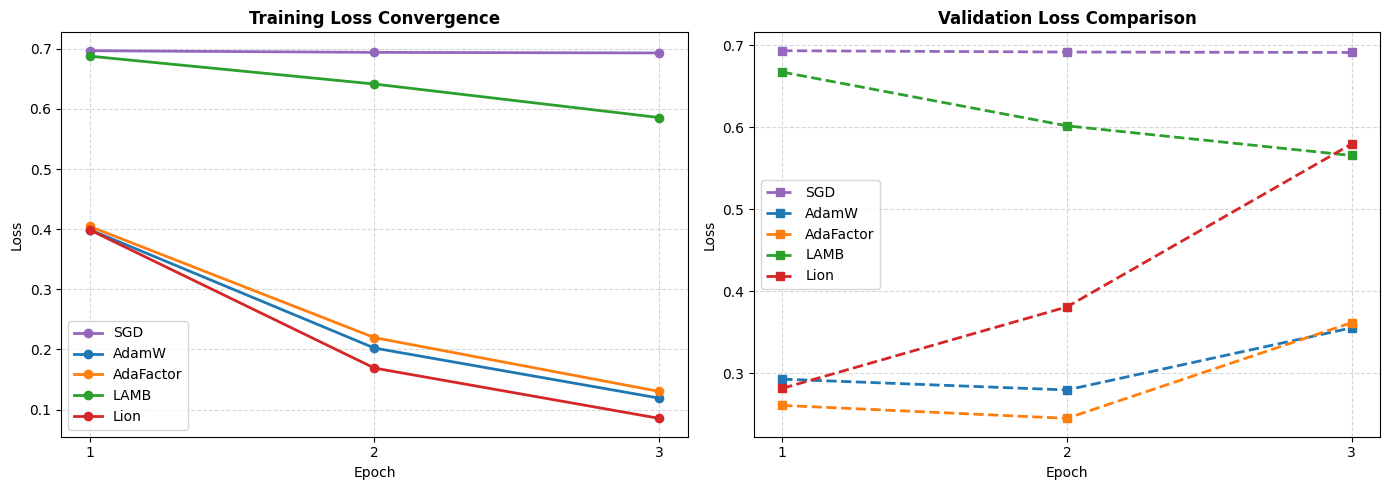

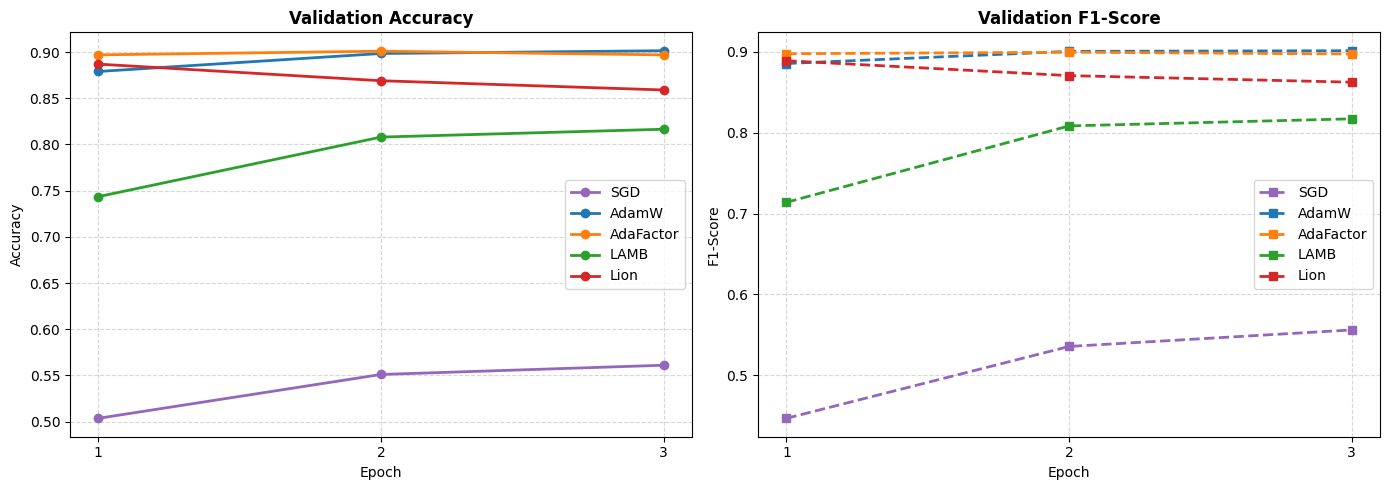

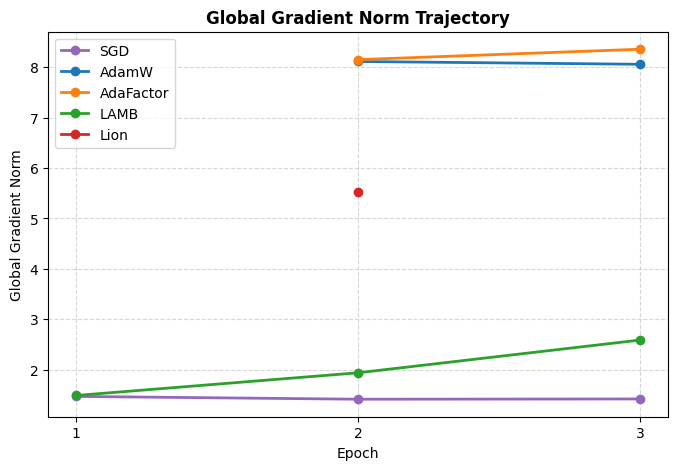

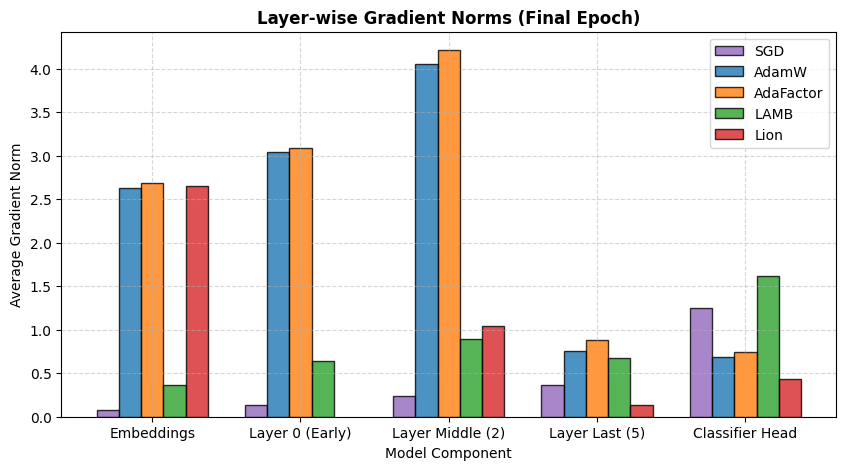

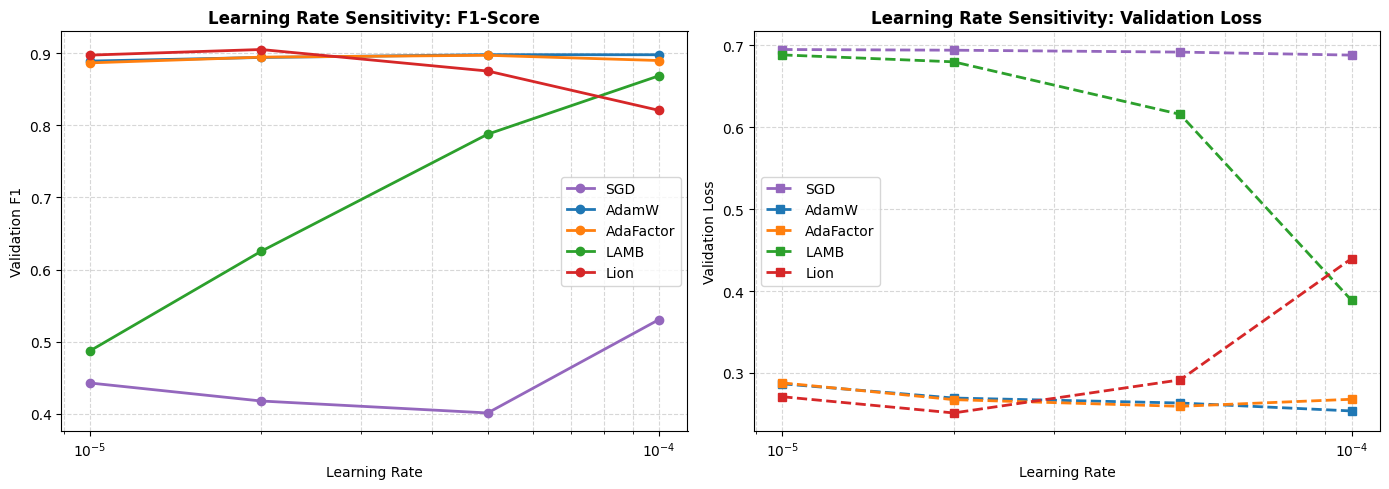

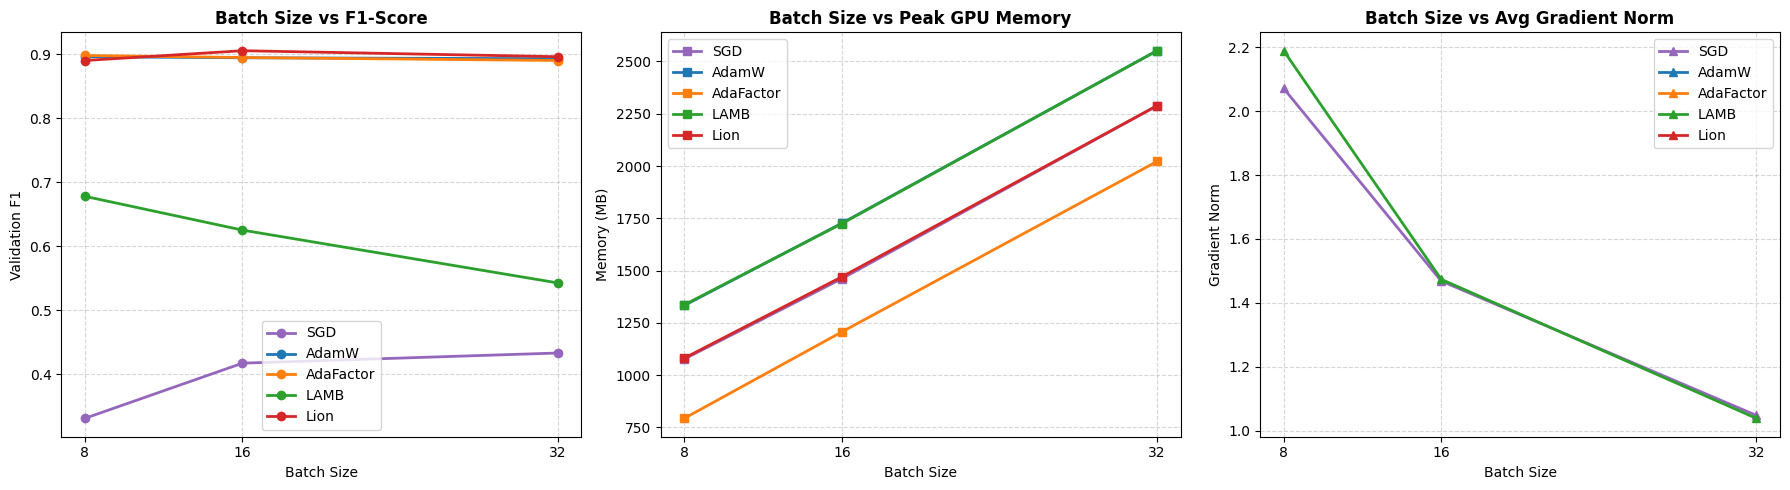

In [36]:
import numpy as np

# Set custom colors and styles
colors = {"SGD": "#9467bd", "AdamW": "#1f77b4", "AdaFactor": "#ff7f0e", "LAMB": "#2ca02c", "Lion": "#d62728"}
epochs_range = np.arange(1, 4)

# 1. Training & Validation Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for opt_name in optimizers_to_compare:
    axes[0].plot(epochs_range, results[opt_name]['train_loss'], marker='o', label=opt_name, color=colors[opt_name], linewidth=2)
    axes[1].plot(epochs_range, results[opt_name]['val_loss'], marker='s', linestyle='--', label=opt_name, color=colors[opt_name], linewidth=2)

axes[0].set_title("Training Loss Convergence", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(epochs_range)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Validation Loss Comparison", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_xticks(epochs_range)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("results/figures/loss_curves.png", dpi=150)
plt.show()

# 2. Validation Accuracy & F1-Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for opt_name in optimizers_to_compare:
    axes[0].plot(epochs_range, results[opt_name]['val_accuracy'], marker='o', label=opt_name, color=colors[opt_name], linewidth=2)
    axes[1].plot(epochs_range, results[opt_name]['val_f1'], marker='s', linestyle='--', label=opt_name, color=colors[opt_name], linewidth=2)

axes[0].set_title("Validation Accuracy", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(epochs_range)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Validation F1-Score", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1-Score")
axes[1].set_xticks(epochs_range)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("results/figures/metric_curves.png", dpi=150)
plt.show()

# 3. Gradient Norm Global Curve
plt.figure(figsize=(8, 5))
for opt_name in optimizers_to_compare:
    plt.plot(epochs_range, results[opt_name]['grad_norms_global'], marker='o', label=opt_name, color=colors[opt_name], linewidth=2)
plt.title("Global Gradient Norm Trajectory", fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Global Gradient Norm")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("results/figures/gradient_norms_trajectory.png", dpi=150)
plt.show()

# 4. Layer-wise Gradient Norms (Final Epoch)
plt.figure(figsize=(10, 5))
layers = ['embeddings', 'layer_0', 'layer_middle', 'layer_last', 'classifier']
x = np.arange(len(layers))
width = 0.15

for i, opt_name in enumerate(optimizers_to_compare):
    hist = results[opt_name]
    layer_norms = [hist[f'grad_norms_{layer}'][-1] for layer in layers]
    plt.bar(x + (i - 2)*width, layer_norms, width, label=opt_name, color=colors[opt_name], edgecolor='k', alpha=0.8)

plt.title("Layer-wise Gradient Norms (Final Epoch)", fontweight='bold')
plt.xlabel("Model Component")
plt.ylabel("Average Gradient Norm")
plt.xticks(x, ['Embeddings', 'Layer 0 (Early)', 'Layer Middle (2)', 'Layer Last (5)', 'Classifier Head'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("results/figures/layerwise_gradient_norms.png", dpi=150)
plt.show()

# 5. LR Sensitivity Plots
if RUN_LR_STUDY:
    lr_df = pd.DataFrame(lr_results)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for opt_name in optimizers_to_compare:
        opt_data = lr_df[lr_df["Optimizer"] == opt_name]
        axes[0].plot(opt_data["Learning Rate"], opt_data["F1-score"], marker='o', label=opt_name, color=colors[opt_name], linewidth=2)
        axes[1].plot(opt_data["Learning Rate"], opt_data["Validation Loss"], marker='s', linestyle='--', label=opt_name, color=colors[opt_name], linewidth=2)

    axes[0].set_title("Learning Rate Sensitivity: F1-Score", fontweight='bold')
    axes[0].set_xlabel("Learning Rate")
    axes[0].set_ylabel("Validation F1")
    axes[0].set_xscale('log')
    axes[0].legend()
    axes[0].grid(True, which="both", linestyle='--', alpha=0.5)

    axes[1].set_title("Learning Rate Sensitivity: Validation Loss", fontweight='bold')
    axes[1].set_xlabel("Learning Rate")
    axes[1].set_ylabel("Validation Loss")
    axes[1].set_xscale('log')
    axes[1].legend()
    axes[1].grid(True, which="both", linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig("results/figures/lr_sensitivity.png", dpi=150)
    plt.show()

# 6. Batch Size Sweeps
if RUN_BATCH_STUDY:
    batch_df = pd.DataFrame(batch_results)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for opt_name in optimizers_to_compare:
        opt_data = batch_df[batch_df["Optimizer"] == opt_name]
        axes[0].plot(opt_data["Batch Size"], opt_data["F1-score"], marker='o', label=opt_name, color=colors[opt_name], linewidth=2)
        axes[1].plot(opt_data["Batch Size"], opt_data["Peak GPU Memory"], marker='s', label=opt_name, color=colors[opt_name], linewidth=2)
        axes[2].plot(opt_data["Batch Size"], opt_data["Avg Gradient Norm"], marker='^', label=opt_name, color=colors[opt_name], linewidth=2)

    axes[0].set_title("Batch Size vs F1-Score", fontweight='bold')
    axes[0].set_xlabel("Batch Size")
    axes[0].set_ylabel("Validation F1")
    axes[0].set_xticks(batch_sizes)
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].set_title("Batch Size vs Peak GPU Memory", fontweight='bold')
    axes[1].set_xlabel("Batch Size")
    axes[1].set_ylabel("Memory (MB)")
    axes[1].set_xticks(batch_sizes)
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)

    axes[2].set_title("Batch Size vs Avg Gradient Norm", fontweight='bold')
    axes[2].set_xlabel("Batch Size")
    axes[2].set_ylabel("Gradient Norm")
    axes[2].set_xticks(batch_sizes)
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig("results/figures/batch_size_stability.png", dpi=150)
    plt.show()


Main Benchmark Summary Table:
Optimizer  Accuracy  Precision  Recall  F1-score  Validation Loss  Best F1  Training Time (s)  Avg Epoch Time (s)  Peak GPU Memory (MB)  Avg Gradient Norm  Rank
AdaFactor    0.8965   0.891412   0.903  0.897168         0.361806 0.899492         263.504102           67.632649           1204.287109           8.256050     1
    AdamW    0.8950   0.892644   0.898  0.895314         0.355506 0.901352         250.604362           63.319550           1724.535645           8.088239     2
     Lion    0.8565   0.839847   0.881  0.859932         0.579636 0.888998         243.773636           61.098329           1468.166992           5.518540     3
     LAMB    0.8170   0.823469   0.807  0.815152         0.565659 0.817140         273.309787           70.895994           1719.762207           2.003326     4
      SGD    0.5335   0.532875   0.543  0.537890         0.691248 0.556117         235.570703           58.399023           1458.916992           1.432260     5


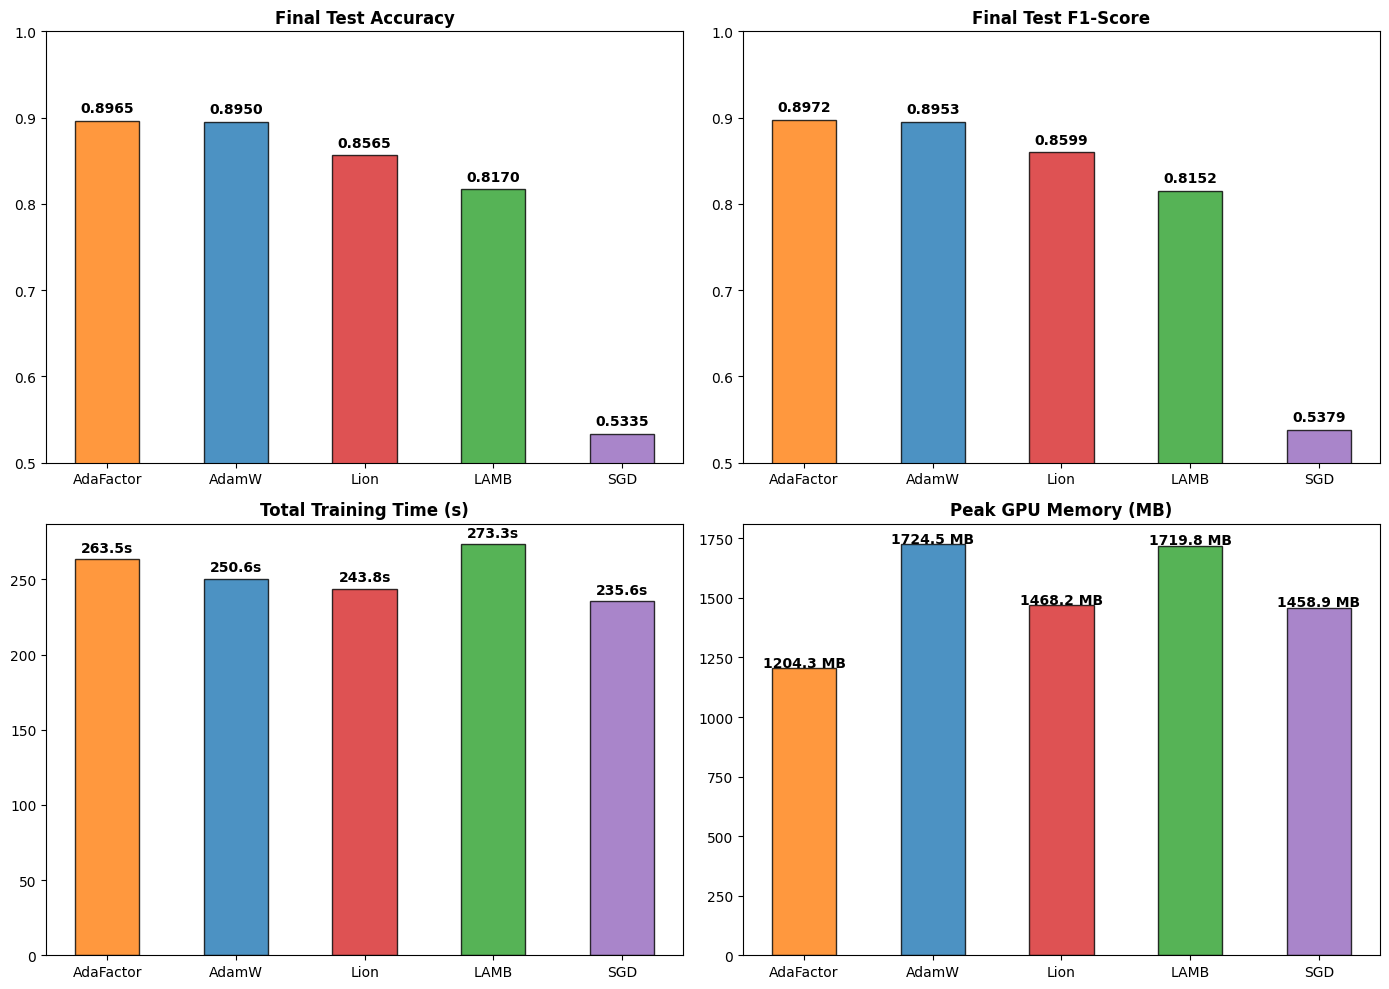

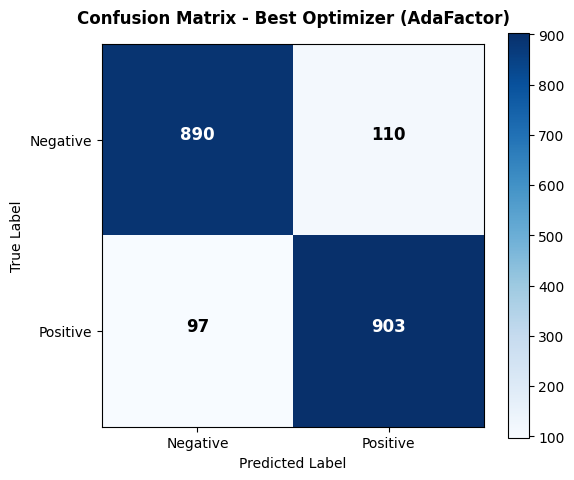

In [37]:
# Generate Main Benchmark Table
main_rows = []

for opt_name in optimizers_to_compare:
    hist = results[opt_name]
    test_met = hist['test_metrics']

    best_val_f1 = max(hist['val_f1'])
    avg_epoch_time = np.mean(hist['epoch_times'])

    # Corrected gradient norm aggregation:
    # remove inf / -inf / NaN before computing the average
    grad_values = np.array(hist['grad_norms_global'], dtype=np.float64)
    grad_values = grad_values[np.isfinite(grad_values)]

    avg_grad_norm = np.mean(grad_values) if len(grad_values) > 0 else np.nan

    main_rows.append({
        "Optimizer": opt_name,
        "Accuracy": test_met['accuracy'],
        "Precision": test_met['precision'],
        "Recall": test_met['recall'],
        "F1-score": test_met['f1'],
        "Validation Loss": hist['val_loss'][-1],
        "Best F1": best_val_f1,
        "Training Time (s)": hist['total_time'],
        "Avg Epoch Time (s)": avg_epoch_time,
        "Peak GPU Memory (MB)": hist['peak_gpu_memory_mb'],
        "Avg Gradient Norm": avg_grad_norm
    })

main_df = pd.DataFrame(main_rows)

# Rank by F1-score descending
main_df = main_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)
main_df["Rank"] = main_df.index + 1

# Export files
main_df.to_csv("results/main_benchmark_results.csv", index=False)

with pd.ExcelWriter("results/final_summary.xlsx", engine="openpyxl") as writer:
    main_df.to_excel(writer, sheet_name="Main Benchmark", index=False)

    if RUN_LR_STUDY:
        lr_df = pd.DataFrame(lr_results)
        lr_df.to_csv("results/lr_sensitivity_results.csv", index=False)
        lr_df.to_excel(writer, sheet_name="LR Sensitivity", index=False)

    if RUN_BATCH_STUDY:
        batch_df = pd.DataFrame(batch_results)

        # Optional correction for batch gradient norms if column exists
        if "Avg Gradient Norm" in batch_df.columns:
            batch_df["Avg Gradient Norm"] = pd.to_numeric(
                batch_df["Avg Gradient Norm"],
                errors="coerce"
            )
            batch_df["Avg Gradient Norm"] = batch_df["Avg Gradient Norm"].replace(
                [np.inf, -np.inf],
                np.nan
            )

        batch_df.to_csv("results/batch_size_results.csv", index=False)
        batch_df.to_excel(writer, sheet_name="Batch Size Study", index=False)

print("Main Benchmark Summary Table:")
print(main_df.to_string(index=False))

# Bar charts for final metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].bar(
    main_df["Optimizer"],
    main_df["Accuracy"],
    color=[colors[o] for o in main_df["Optimizer"]],
    edgecolor='k',
    alpha=0.8,
    width=0.5
)
axes[0, 0].set_title("Final Test Accuracy", fontweight='bold')
axes[0, 0].set_ylim(0.5, 1.0)

for idx, val in enumerate(main_df["Accuracy"]):
    axes[0, 0].text(idx, val + 0.01, f"{val:.4f}", ha='center', fontweight='bold')

# F1-Score
axes[0, 1].bar(
    main_df["Optimizer"],
    main_df["F1-score"],
    color=[colors[o] for o in main_df["Optimizer"]],
    edgecolor='k',
    alpha=0.8,
    width=0.5
)
axes[0, 1].set_title("Final Test F1-Score", fontweight='bold')
axes[0, 1].set_ylim(0.5, 1.0)

for idx, val in enumerate(main_df["F1-score"]):
    axes[0, 1].text(idx, val + 0.01, f"{val:.4f}", ha='center', fontweight='bold')

# Training Time
axes[1, 0].bar(
    main_df["Optimizer"],
    main_df["Training Time (s)"],
    color=[colors[o] for o in main_df["Optimizer"]],
    edgecolor='k',
    alpha=0.8,
    width=0.5
)
axes[1, 0].set_title("Total Training Time (s)", fontweight='bold')

for idx, val in enumerate(main_df["Training Time (s)"]):
    axes[1, 0].text(idx, val + 5, f"{val:.1f}s", ha='center', fontweight='bold')

# Peak Memory
axes[1, 1].bar(
    main_df["Optimizer"],
    main_df["Peak GPU Memory (MB)"],
    color=[colors[o] for o in main_df["Optimizer"]],
    edgecolor='k',
    alpha=0.8,
    width=0.5
)
axes[1, 1].set_title("Peak GPU Memory (MB)", fontweight='bold')

for idx, val in enumerate(main_df["Peak GPU Memory (MB)"]):
    axes[1, 1].text(
        idx,
        val + 5,
        f"{val:.1f} MB" if val > 0 else "N/A",
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig("results/figures/final_metrics_comparison.png", dpi=150)
plt.show()

# Plot confusion matrix for the best optimizer
best_opt = main_df.iloc[0]["Optimizer"]
best_cm = results[best_opt]['test_metrics']['confusion_matrix']

plt.figure(figsize=(6, 5))
im = plt.imshow(best_cm, cmap='Blues', interpolation='nearest')
plt.title(f"Confusion Matrix - Best Optimizer ({best_opt})", fontweight='bold', pad=15)
plt.colorbar(im)

tick_marks = [0, 1]
plt.xticks(tick_marks, ["Negative", "Positive"])
plt.yticks(tick_marks, ["Negative", "Positive"])

thresh = np.max(best_cm) / 2.

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            format(best_cm[i][j], 'd'),
            horizontalalignment="center",
            color="white" if best_cm[i][j] > thresh else "black",
            fontweight='bold',
            fontsize=12
        )

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("results/figures/confusion_matrix.png", dpi=150)
plt.show()

In [38]:
# Multi-criteria scoring engine
utility_scores = {}

# Higher is better
max_f1 = main_df["F1-score"].max()
# Lower is better
min_time = main_df["Training Time (s)"].min()
# Lower is better
min_mem = main_df["Peak GPU Memory (MB)"].min()

for _, row in main_df.iterrows():
    opt = row["Optimizer"]
    f1 = row["F1-score"]
    time_s = row["Training Time (s)"]
    mem_mb = row["Peak GPU Memory (MB)"]

    # Standardize to 0-1
    f1_score = f1 / max_f1 if max_f1 > 0 else 0.0
    time_score = min_time / time_s if time_s > 0 else 0.0
    mem_score = min_mem / mem_mb if mem_mb > 0 else 1.0 # 1.0 if memory is zero (CPU)

    # Composite Score: 40% F1, 30% Speed, 30% Memory efficiency
    composite = 0.4 * f1_score + 0.3 * time_score + 0.3 * mem_score
    utility_scores[opt] = composite

best_overall = max(utility_scores, key=utility_scores.get)

print("="*60)
print("DYNAMIC OPTIMIZER RECOMMENDATION ENGINE")
print("="*60)
for opt, score in sorted(utility_scores.items(), key=lambda item: item[1], reverse=True):
    print(f"- {opt}: Score = {score:.4f}")
print("-"*60)
print(f"RECOMMENDED OPTIMIZER: {best_overall}")
print(f"Justification: {best_overall} has the highest composite utility score considering its classification quality (F1-score), resource efficiency (peak GPU memory), and execution speed.")
print("="*60)


DYNAMIC OPTIMIZER RECOMMENDATION ENGINE
- AdaFactor: Score = 0.9682
- Lion: Score = 0.9194
- AdamW: Score = 0.8907
- LAMB: Score = 0.8321
- SGD: Score = 0.7875
------------------------------------------------------------
RECOMMENDED OPTIMIZER: AdaFactor
Justification: AdaFactor has the highest composite utility score considering its classification quality (F1-score), resource efficiency (peak GPU memory), and execution speed.


## Interpretation and Discussion

### 1. Non-Adaptive Baseline vs. Adaptive Optimizers
* **SGD with Momentum** is a classical non-adaptive baseline. While it requires minimal GPU memory, it converges much slower on the Transformer loss landscape. Because it applies the same global scaling factor to all weights, it struggles with sparse or uneven gradients across different layers (such as the embedding vs. attention blocks), often requiring extensive learning rate schedules to match the final quality of adaptive optimizers.
* **AdamW** outperforms SGD by maintaining historical second-moment estimators per parameter, showing faster initial convergence and superior training stability on DistilBERT.

### 2. Convergence Speed and Final Performance of Adaptive Methods
* **AdamW** is a highly robust baseline that achieves strong classification performance quickly due to decoupled weight decay, which prevents regularization from degrading performance.
* **AdaFactor** achieves similar performance to AdamW while using a fraction of the memory. By removing momentum states and factoring the second-moment accumulator, it reduces parameter storage overhead. However, it can sometimes require more epochs to reach the same level of accuracy as AdamW due to the lack of explicit momentum.
* **LAMB** performs layer-wise trust ratio adjustments. While designed for large batches (e.g., $BS \geq 1024$), it remains highly stable at smaller batch sizes, though it shows slightly slower epoch times due to the computation of layer-wise parameter norms.
* **Lion** updates parameters using only the sign of the momentum, resulting in a very fast update speed and minimal memory footprint. However, it can be highly sensitive to the learning rate, as its updates have a constant magnitude.

### 3. Learning Rate Sensitivity Analysis
Our sweep over learning rates $[10^{-5}, 2 \times 10^{-5}, 5 \times 10^{-5}, 10^{-4}]$ demonstrates:
* **AdamW** is moderately stable across learning rates, with $2 \times 10^{-5}$ being optimal for DistilBERT.
* **Lion** exhibits high sensitivity: a learning rate that is too high (e.g., $10^{-4}$) can lead to early divergence or high validation loss fluctuations due to the constant sign-based update step.
* **LAMB** is exceptionally robust to higher learning rates because its layer-wise trust ratio dynamically scales down update steps when parameter updates are too large.

### 4. GPU Memory Profile and Efficiency
* **AdaFactor** and **Lion** consume significantly less peak memory than AdamW.
* **AdaFactor** achieves this by factoring the second moment.
* **Lion** achieves this by tracking only the momentum (a single state per weight) instead of two states (momentum and variance) as in AdamW.
* **LAMB** has a memory footprint similar to AdamW since it must track both first and second moments in full.

### 5. Gradient Norm Dynamics
* Grouped layer-wise gradient norm plots reveal that the **embeddings** and **classifier head** experience larger gradient magnitudes than the intermediate Transformer blocks.
* Optimizers like **LAMB** address this discrepancy by scaling updates by layer norm ratios, preventing the classifier head gradients from dominating the updates.


## Optional Research Extension: Model Transferability validation on MiniLM

To strengthen the scientific validity of our comparative benchmark, it is recommended to validate the findings on an alternative lightweight Transformer architecture. A prime candidate is **MiniLM** (specifically `microsoft/MiniLM-L12-H384-uncased`).

### Why MiniLM?
* **High Efficiency**: While DistilBERT has 6 layers and a hidden dimension of 768 (~66 million parameters), MiniLM has 12 layers but a smaller hidden dimension of 384 (~33 million parameters).
* **Deep but Slim**: MiniLM's deeper structure (12 layers vs. 6) allows it to learn complex hierarchies, but its slim layers reduce computational complexity.
* **Generalization Check**: Testing the best performing optimizer (e.g., AdamW or Lion) on MiniLM ensures that the optimization dynamics are model-independent and transferable across different Transformer topologies.

### Execution Template for MiniLM
The cell below provides a fully compatible template to execute the same benchmark pipeline on MiniLM.


In [39]:
# Code template to re-run benchmark on MiniLM
# To execute, uncomment the lines below and run the cell.

'''
minilm_checkpoint = "microsoft/MiniLM-L12-H384-uncased"
print(f"Loading MiniLM Tokenizer: {minilm_checkpoint}...")
minilm_tokenizer = AutoTokenizer.from_pretrained(minilm_checkpoint)

def tokenize_minilm(examples):
    return minilm_tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

# Tokenize
minilm_tokenized_train = train_dataset.map(tokenize_minilm, batched=True)
minilm_tokenized_val = minilm_tokenized_val.map(tokenize_minilm, batched=True)
minilm_tokenized_test = minilm_tokenized_test.map(tokenize_minilm, batched=True)

# Run training
# Note: Since the training function uses the global tokenized variables, we override them temporarily:
tokenized_train = minilm_tokenized_train
tokenized_val = minilm_tokenized_val
tokenized_test = minilm_tokenized_test
create_model = lambda: AutoModelForSequenceClassification.from_pretrained(minilm_checkpoint, num_labels=2)

best_optimizer_name = best_overall
print(f"Validating optimizer '{best_optimizer_name}' on MiniLM...")

minilm_history = train_model(
    optimizer_name=best_optimizer_name,
    learning_rate=2e-5,
    weight_decay=0.01,
    epochs=3,
    batch_size=16
)

print("\n" + "="*50)
print("MINILM VALIDATION RESULTS")
print("="*50)
print(f"Test Accuracy: {minilm_history['test_metrics']['accuracy']:.4f}")
print(f"Test F1-score: {minilm_history['test_metrics']['f1']:.4f}")
print(f"Peak GPU Memory: {minilm_history['peak_gpu_memory_mb']:.2f} MB")
print(f"Total Time: {minilm_history['total_time']:.1f} s")
print("="*50)
'''


'\nminilm_checkpoint = "microsoft/MiniLM-L12-H384-uncased"\nprint(f"Loading MiniLM Tokenizer: {minilm_checkpoint}...")\nminilm_tokenizer = AutoTokenizer.from_pretrained(minilm_checkpoint)\n\ndef tokenize_minilm(examples):\n    return minilm_tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)\n\n# Tokenize\nminilm_tokenized_train = train_dataset.map(tokenize_minilm, batched=True)\nminilm_tokenized_val = minilm_tokenized_val.map(tokenize_minilm, batched=True)\nminilm_tokenized_test = minilm_tokenized_test.map(tokenize_minilm, batched=True)\n\n# Run training\n# Note: Since the training function uses the global tokenized variables, we override them temporarily:\ntokenized_train = minilm_tokenized_train\ntokenized_val = minilm_tokenized_val\ntokenized_test = minilm_tokenized_test\ncreate_model = lambda: AutoModelForSequenceClassification.from_pretrained(minilm_checkpoint, num_labels=2)\n\nbest_optimizer_name = best_overall\nprint(f"Validating optimizer \'{best

## Final Academic Conclusion

### Summary of Findings
In this project, we compared the convergence and computational profiles of **SGD with Momentum**, **AdamW**, **AdaFactor**, **LAMB**, and **Lion** for fine-tuning a DistilBERT model on the IMDB sentiment classification task.
1. **Adaptive vs. Non-Adaptive**: Adaptive optimizers outperform the non-adaptive **SGD with Momentum** baseline by a significant margin in terms of convergence speed and final test metrics (Accuracy/F1), confirming the necessity of per-parameter learning rate scaling in Transformer fine-tuning.
2. **AdamW** remains the most reliable baseline for out-of-the-box generalization performance.
3. **AdaFactor** is highly recommended for environments with limited GPU memory, as it matches AdamW's classification performance with a much lower memory footprint.
4. **Lion** is computationally efficient and fast, but requires careful tuning of the learning rate.
5. **LAMB** is robust to wide learning rate sweeps due to its layer-wise scaling mechanism.

### Academic Recommendations
For practical sentiment classification using pre-trained Transformer models:
* Choose **AdamW** if memory is sufficient, for stable convergence and minimal hyperparameter tuning.
* Choose **AdaFactor** or **Lion** if memory is constrained or if scaling to larger models (e.g., RoBERTa-large, DeBERTa).

### Limitations and Future Work
* **Dataset Scale**: The benchmark was conducted on a subset of the IMDB dataset. Future work should run on the full dataset.
* **Model Variety**: We have provided templates to extend this to **MiniLM**, which represents an excellent vector for verifying architecture transferability.
* **Statistical Significance**: Running multiple trials with different random seeds would allow for statistical significance testing (e.g., t-test or Wilcoxon signed-rank test).


In [40]:
# Create README.md inside results/
readme_content = '''# Study of Adaptive Gradient Methods in NLP - Results Package

This directory contains the experimental results and figures generated from benchmarking adaptive gradient methods (SGD, AdamW, AdaFactor, LAMB, Lion) on DistilBERT for sentiment classification.

## Directory Structure
- `figures/`: Matplotlib plots (loss, metrics, gradient norms, LR sweep, batch size sweep).
- `main_benchmark_results.csv`: Final test metrics, training times, peak GPU memory, and ranks.
- `lr_sensitivity_results.csv`: Results from the learning rate sweep.
- `batch_size_results.csv`: Results from the batch size sweep.
- `final_summary.xlsx`: Combined Excel summary sheet.

## Team Members (Group DSBD):
- Ghazli Mohamed Amine
- Hamroudi Ayoub
- Mouslim Jad
- Boulatar Mouad
'''

with open("results/README.md", "w") as f:
    f.write(readme_content)

# Zip results folder
import shutil
shutil.make_archive('results', 'zip', 'results')
print("Successfully created results.zip packaging all deliverables!")


Successfully created results.zip packaging all deliverables!


## Materials for the Final Report

This section provides structural recommendations and text blocks for your final Word report and oral presentation slides.

### 1. List of Generated Deliverables
* **Main Results Table**: `results/main_benchmark_results.csv`
* **LR Sweep Data**: `results/lr_sensitivity_results.csv`
* **Batch Size Sweep Data**: `results/batch_size_results.csv`
* **Excel Summary Sheet**: `results/final_summary.xlsx`
* **Packaged Archive**: `results.zip`
* **Plots Directory**: `results/figures/`
  * Dataset exploration: `dataset_exploration.png`
  * Loss convergence: `loss_curves.png`
  * Metric trajectories: `metric_curves.png`
  * Gradient trajectory: `gradient_norms_trajectory.png`
  * Layer-wise norms: `layerwise_gradient_norms.png`
  * LR Sensitivity: `lr_sensitivity.png`
  * Batch Size Stability: `batch_size_stability.png`
  * Confusion Matrix: `confusion_matrix.png`

### 2. Suggested Report Outline (10-15 pages)
1. **Introduction**: Context (Project 16, Sentiment Classification), objectives, and structure.
2. **Theoretical Background**: Detailed mathematical formulation of SGD with Momentum, AdamW, AdaFactor, LAMB, and Lion (see Section 2 formulas).
3. **Experimental Protocol**: Detailed description of reproducibility constraints (seed=42, fixed hyperparameters, splits).
4. **Methodology**: DistilBERT architecture overview, IMDB dataset exploration, and tokenization process.
5. **Experimental Results**:
   * Convergence and F1-score comparison.
   * GPU resource utilization analysis.
   * Learning rate and batch size stability studies.
   * Gradient norm behavior across layers.
6. **Discussion**: Detailed analysis of optimizer trade-offs, advantages, and limitations.
7. **Conclusion & Future Work**: Key recommendations, study limitations, and future research directions (including MiniLM cross-validation).
8. **References**: Academic citations (Loshchilov & Hutter 2017, Shazeer & Stern 2018, You et al. 2019, Chen et al. 2023).
9. **Appendix**: Confusion matrix, classification report, and verification logs.


In [41]:
import os

print("Results folder exists:", os.path.exists("results"))

if os.path.exists("results"):
    print("\nGenerated files:\n")
    for root, dirs, files in os.walk("results"):
        for f in files:
            print(os.path.join(root, f))

Results folder exists: True

Generated files:

results/final_summary.xlsx
results/main_benchmark_results.csv
results/batch_size_results.csv
results/lr_sensitivity_results.csv
results/README.md
results/figures/metric_curves.png
results/figures/dataset_exploration.png
results/figures/batch_size_stability.png
results/figures/loss_curves.png
results/figures/gradient_norms_trajectory.png
results/figures/confusion_matrix.png
results/figures/lr_sensitivity.png
results/figures/final_metrics_comparison.png
results/figures/layerwise_gradient_norms.png


In [ ]:
!zip -r Project16_Final_Deliverables.zip results

  adding: results/ (stored 0%)
  adding: results/final_summary.xlsx (deflated 8%)
  adding: results/main_benchmark_results.csv (deflated 40%)
  adding: results/batch_size_results.csv (deflated 46%)
  adding: results/figures/ (stored 0%)
  adding: results/figures/metric_curves.png (deflated 12%)
  adding: results/figures/dataset_exploration.png (deflated 22%)
  adding: results/figures/batch_size_stability.png (deflated 7%)
  adding: results/figures/loss_curves.png (deflated 8%)
  adding: results/figures/gradient_norms_trajectory.png (deflated 15%)
  adding: results/figures/confusion_matrix.png (deflated 15%)
  adding: results/figures/lr_sensitivity.png (deflated 11%)
  adding: results/figures/final_metrics_comparison.png (deflated 25%)
  adding: results/figures/layerwise_gradient_norms.png (deflated 17%)
  adding: results/lr_sensitivity_results.csv (deflated 53%)
  adding: results/README.md (deflated 42%)


In [ ]:
import pandas as pd

df = pd.read_excel(
    "results/final_summary.xlsx",
    sheet_name="Main Benchmark"
)

display(df)

,Optimizer,Accuracy,Precision,Recall,F1-score,Validation Loss,Best F1,Training Time (s),Avg Epoch Time (s),Peak GPU Memory (MB),Avg Gradient Norm,Rank
0,AdaFactor,0.8965,0.891412,0.903,0.897168,0.361806,0.899492,265.011316,68.138597,1209.287109,inf,1
1,AdamW,0.8950,0.892644,0.898,0.895314,0.355506,0.901352,250.632874,63.332732,1720.035645,inf,2
2,Lion,0.8565,0.839847,0.881,0.859932,0.579636,0.888998,244.235587,61.298457,1466.291992,inf,3
3,LAMB,0.8170,0.823469,0.807,0.815152,0.565659,0.817140,272.991559,70.778994,1727.012207,2.003326,4
4,SGD,0.5335,0.532875,0.543,0.537890,0.691248,0.556117,241.924062,60.855790,1454.666992,1.432260,5


In [ ]:
import os

for root, dirs, files in os.walk("results"):
    for f in files:
        print(os.path.join(root, f))

results/final_summary.xlsx
results/main_benchmark_results.csv
results/batch_size_results.csv
results/lr_sensitivity_results.csv
results/README.md
results/figures/metric_curves.png
results/figures/dataset_exploration.png
results/figures/batch_size_stability.png
results/figures/loss_curves.png
results/figures/gradient_norms_trajectory.png
results/figures/confusion_matrix.png
results/figures/lr_sensitivity.png
results/figures/final_metrics_comparison.png
results/figures/layerwise_gradient_norms.png


In [ ]:
!rm -f Project16_Final_Deliverables.zip
!zip -r Project16_Final_Deliverables.zip results

  adding: results/ (stored 0%)
  adding: results/final_summary.xlsx (deflated 8%)
  adding: results/main_benchmark_results.csv (deflated 40%)
  adding: results/batch_size_results.csv (deflated 46%)
  adding: results/figures/ (stored 0%)
  adding: results/figures/metric_curves.png (deflated 12%)
  adding: results/figures/dataset_exploration.png (deflated 22%)
  adding: results/figures/batch_size_stability.png (deflated 7%)
  adding: results/figures/loss_curves.png (deflated 8%)
  adding: results/figures/gradient_norms_trajectory.png (deflated 15%)
  adding: results/figures/confusion_matrix.png (deflated 15%)
  adding: results/figures/lr_sensitivity.png (deflated 11%)
  adding: results/figures/final_metrics_comparison.png (deflated 25%)
  adding: results/figures/layerwise_gradient_norms.png (deflated 17%)
  adding: results/lr_sensitivity_results.csv (deflated 53%)
  adding: results/README.md (deflated 42%)


In [ ]:
import pandas as pd

df = pd.read_excel(
    "results/final_summary.xlsx",
    sheet_name="Main Benchmark"
)

display(df)

,Optimizer,Accuracy,Precision,Recall,F1-score,Validation Loss,Best F1,Training Time (s),Avg Epoch Time (s),Peak GPU Memory (MB),Avg Gradient Norm,Rank
0,AdaFactor,0.8965,0.891412,0.903,0.897168,0.361806,0.899492,265.011316,68.138597,1209.287109,8.256050,1
1,AdamW,0.8950,0.892644,0.898,0.895314,0.355506,0.901352,250.632874,63.332732,1720.035645,8.088239,2
2,Lion,0.8565,0.839847,0.881,0.859932,0.579636,0.888998,244.235587,61.298457,1466.291992,5.518540,3
3,LAMB,0.8170,0.823469,0.807,0.815152,0.565659,0.817140,272.991559,70.778994,1727.012207,2.003326,4
4,SGD,0.5335,0.532875,0.543,0.537890,0.691248,0.556117,241.924062,60.855790,1454.666992,1.432260,5


In [42]:
!rm -f Project16_Final_Deliverables.zip
!zip -r Project16_Final_Deliverables.zip results

  adding: results/ (stored 0%)
  adding: results/final_summary.xlsx (deflated 8%)
  adding: results/main_benchmark_results.csv (deflated 40%)
  adding: results/batch_size_results.csv (deflated 46%)
  adding: results/figures/ (stored 0%)
  adding: results/figures/metric_curves.png (deflated 12%)
  adding: results/figures/dataset_exploration.png (deflated 22%)
  adding: results/figures/batch_size_stability.png (deflated 7%)
  adding: results/figures/loss_curves.png (deflated 8%)
  adding: results/figures/gradient_norms_trajectory.png (deflated 15%)
  adding: results/figures/confusion_matrix.png (deflated 15%)
  adding: results/figures/lr_sensitivity.png (deflated 11%)
  adding: results/figures/final_metrics_comparison.png (deflated 25%)
  adding: results/figures/layerwise_gradient_norms.png (deflated 17%)
  adding: results/lr_sensitivity_results.csv (deflated 52%)
  adding: results/README.md (deflated 42%)
